### Comparing subcritical analytical informed to numerical solution


In [ ]:
include("subcrit_circle.jl")
include(relpath("subcritical_elliptical/sub_elliptical.jl","shape_in_wdp"))
using LinearAlgebra

In [8]:
v = 0.75
l = pi

π = 3.1415926535897...

### Do same optimisation with analytically informed and numerical optimisation

In [48]:
A = param_ellipse(v,l,l,5l,5l,150)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   420656
Number of nonzeros in inequality constraint Jacobian.:     2178
Number of nonzeros in Lagrangian Hessian.............:    30568

Total number of variables............................:    91213
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:    91204
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -6.7762636e-21 3.06e-01 1.64e-03  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; 0.0 1.9699921300244244e-21 … 2.5269606462186087e-19 0.0; … ; 0.0 -1.1586764156406862e-21 … -2.552612258936891e-19 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 1.2733686232154996e-20 … 2.5666084165870865e-19 0.0; … ; 0.0 -1.6342729089358372e-20 … -2.5526427970840624e-19 0.0; 0.0 0.0 … 0.0 0.0], [0.051489798227404265 0.0545557901244733 … -0.004376097281932243 -0.006265032263962059; 0.06686785884814156 0.06961343461615209 … -0.0033578006904852664 -0.005732144993128438; … ; 0.06472848198112749 0.06749989338154412 … -0.003461541107262849 -0.00585561251916133; 0.04924858782548352 0.05234182709038942 … -0.004495920153880872 -0.0063907279796628046], [0.11727352725276168 0.11438858614046392 … 0.00512009433914633 0.0023999962280610546; 0.11081780252297836 0.1074854507305514 … 0.005837449045251531 0.003472451372072375; … ; 0.11179167461739484 0.10848208098007509 … 0.005910666481736733 0.0034991429861465796; 0.11793238586911084 0.11508201346148775 … 0.005163528897503001 0.

In [49]:
B = sub_ellipse(v,l,l,5l,5l,150)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   406596
Number of nonzeros in inequality constraint Jacobian.:     2178
Number of nonzeros in Lagrangian Hessian.............:     6666

Total number of variables............................:    91204
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    89798
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -6.7762636e-21 1.10e-01 7.57e-03  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; 0.0 -1.0323190521183402e-28 … 5.494275243153177e-27 0.0; … ; 0.0 4.970003378199541e-28 … 1.5028595906040334e-26 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 -5.213428911334712e-28 … -5.1228130575391355e-27 0.0; … ; 0.0 -2.4363191813795357e-28 … 9.53184711276158e-27 0.0; 0.0 0.0 … 0.0 0.0], [0.050661058594957314 0.053791458524621964 … -0.0006316481523218207 -0.0012059749271883257; 0.06601671598889391 0.06883190708101475 … -0.0003676402968094145 -0.001019428863146912; … ; 0.06423854942851016 0.06707392044305567 … -0.0004267532609949754 -0.0010871404036638446; 0.048798587094395905 0.051951478870935514 … -0.0006977922006864323 -0.0012734299333859286], [0.11749979856075173 0.11467735244917063 … 0.001386062605218542 0.0009020148632655163; 0.11111913156238355 0.1078416657430628 … 0.0014646590234282293 0.0010880996177271196; … ; 0.1119246883992897 0.10866183542248325 … 0.0014999561337608735 0.001094320259279679; 0.11804105750314782 0.11524441443772922 … 0.0014062728152

### Compare visually

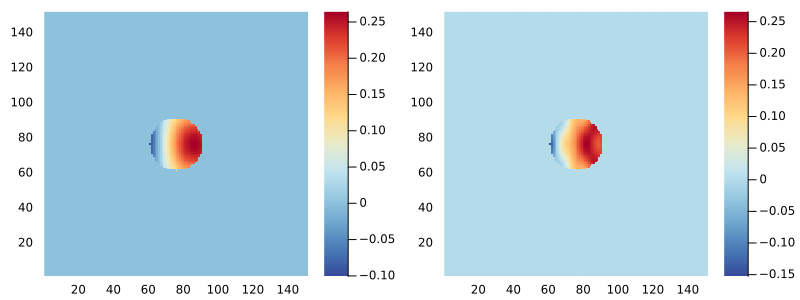

In [50]:
plot(heatmap(A[1]),heatmap(B[1]),size=(800,300))

### They are a little different

#### Run through the points and get absolute difference 

In [ ]:
n = length(A[1][:,1])
real_dif = zeros(n,n)
imag_dif = zeros(n,n)
dif = zeros(n,n)
for xi in 1:n(b
    for yi in 1:n
        re = A[1][yi,xi] - B[1][yi,xi];
        im = A[2][yi,xi] - B[2][yi,xi];
        real_dif[yi,xi] = abs(re);
        imag_dif[yi,xi] = abs(im);
        dif[yi,xi] = sqrt(re^2 + im^2);
    end
end

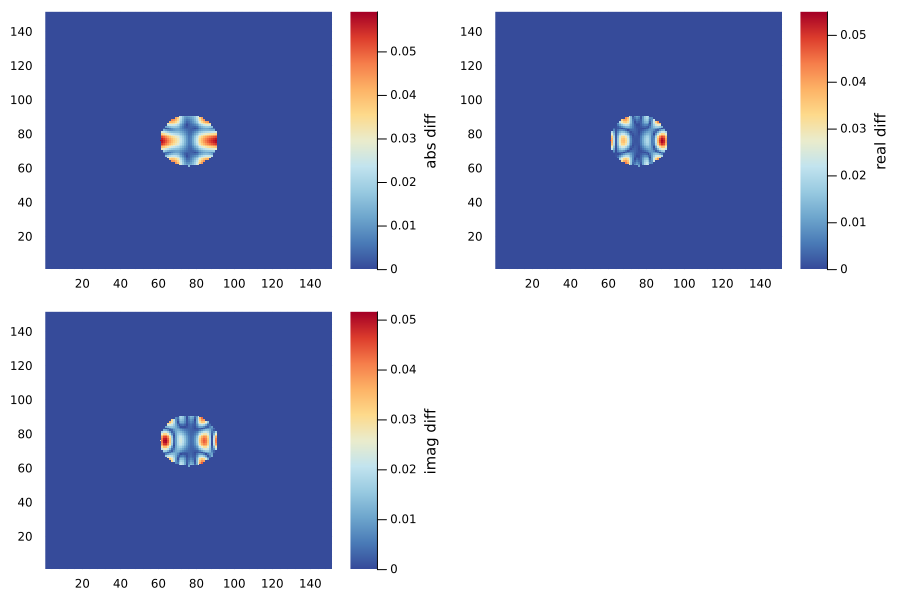

In [52]:
plot(heatmap(dif,colorbar_title="abs diff"),
    heatmap(real_dif,colorbar_title="real diff"),
    heatmap(imag_dif,colorbar_title="imag diff"),size=(900,600))

In [53]:
print(abs(A[11]-B[11])/B[11]*100,"% difference in thrust")

3.7487162315555835% difference in thrust

#### Check $\mathcal{L}\hat{Q}$ error

In [11]:
dx = A[5]
dy = A[10]
a = l/2
b = l/2
lq_real = zeros(n,n)
lq_imag = zeros(n,n)
lq_rcentre = zeros(n,n)
for xi in 1:n
    for yi in 1:n
        x = -5l/2 + (xi-1)*dx
        y = -5l/2 + (yi-1)*dy
        if (x/a)^2 + (y/b)^2 > 1-dy
            # @consxrainx(opxi, Q_real[yi,xi] == 0);
            # @consxrainx(opxi, Q_imag[yi,xi] == 0);
        elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y<0 && x<0
            re = ((1-v^2)*second_forw_x(A[1],dx,yi,xi)
                            + 2*v*first_forw_x(A[2],dx,yi,xi) 
                            + second_forw_y(A[1],dy,yi,xi) 
                            + A[1][yi,xi])
            im = ((1-v^2)*second_forw_x(A[2],dx,yi,xi) 
                            - 2*v*first_forw_x(A[1],dx,yi,xi)
                            + second_forw_y(A[2],dy,yi,xi) 
                            + A[2][yi,xi])
            lq_real[yi,xi] = abs(re)
            lq_imag[yi,xi] = abs(im)
        elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y>=0 && x>=0
            re = ((1-v^2)*second_back_x(A[1],dx,yi,xi)
                            + 2*v*first_back_x(A[2],dx,yi,xi) 
                            + second_back_y(A[1],dy,yi,xi) 
                            + A[1][yi,xi])
            im = ((1-v^2)*second_back_x(A[2],dx,yi,xi) 
                            - 2*v*first_back_x(A[1],dx,yi,xi)
                            + second_back_y(A[2],dy,yi,xi) 
                            + A[2][yi,xi])
            lq_real[yi,xi] = abs(re)
            lq_imag[yi,xi] = abs(im)
        elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y<0 && x>=0
            re = ((1-v^2)*second_back_x(A[1],dx,yi,xi)
                            + 2*v*first_back_x(A[2],dx,yi,xi) 
                            + second_forw_y(A[1],dy,yi,xi) 
                            + A[1][yi,xi])
            im = ((1-v^2)*second_back_x(A[2],dx,yi,xi) 
                            - 2*v*first_back_x(A[1],dx,yi,xi)
                            + second_forw_y(A[2],dy,yi,xi) 
                            + A[2][yi,xi])
            lq_real[yi,xi] = abs(re)
            lq_imag[yi,xi] = abs(im)
        elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y>=0 && x<0
            re = ((1-v^2)*second_forw_x(A[1],dx,yi,xi)
                            + 2*v*first_forw_x(A[2],dx,yi,xi) 
                            + second_back_y(A[1],dy,yi,xi) 
                            + A[1][yi,xi])
            im = ((1-v^2)*second_forw_x(A[2],dx,yi,xi) 
                            - 2*v*first_forw_x(A[1],dx,yi,xi)
                            + second_back_y(A[2],dy,yi,xi) 
                            + A[2][yi,xi])
            lq_real[yi,xi] = abs(re)
            lq_imag[yi,xi] = abs(im)
        elseif (x/a)^2 + (y/b)^2 <= 1- 2*dy
            re = ((1-v^2)*second_centred_x(A[1],dx,yi,xi)
                            + 2*v*first_centred_x(A[2],dx,yi,xi) 
                            + second_centred_y(A[1],dy,yi,xi) 
                            + A[1][yi,xi])
            im = ((1-v^2)*second_centred_x(A[2],dx,yi,xi) 
                            - 2*v*first_centred_x(A[1],dx,yi,xi)
                            + second_centred_y(A[2],dy,yi,xi) 
                            + A[2][yi,xi])
            lq_real[yi,xi] = abs(re)
            lq_imag[yi,xi] = abs(im)
            lq_rcentre[yi,xi] = abs(re)
        end
    end
end

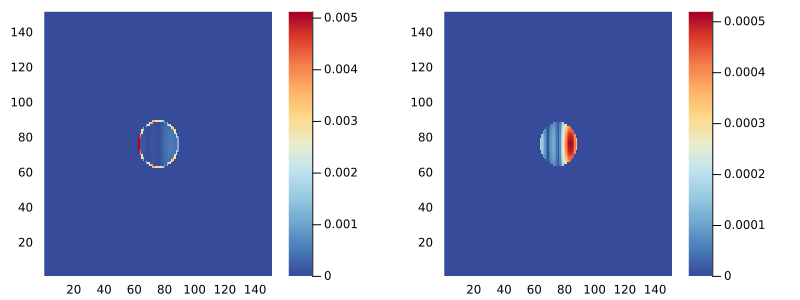

In [12]:
theme(:vibrant)
plot(heatmap(lq_real,right_margin=1Plots.cm),heatmap(lq_rcentre,right_margin=1Plots.cm),size=(800,300))

### Sweep comparing thrust 
This is the easiest way to compare since the solution has arbitrary argument

In [9]:
max_rdif = []
max_idif = []
max_dif = []
thrust_dif = []
thrust_ana = []
thrust_num = []
op_ana = []
glob_ana = []
op_num = []
glob_num = []
for vel in 0:0.05:0.95
    A = param_ellipse(vel,l,l,5l,5l,100,true)
    B = sub_ellipse(vel,l,l,5l,5l,100,true)
    n = length(A[1][:,1])
    real_dif = zeros(n,n)
    imag_dif = zeros(n,n)
    dif = zeros(n,n)
    for xi in 1:n
        for yi in 1:n
            re = A[1][yi,xi] - B[1][yi,xi];
            im = A[2][yi,xi] - B[2][yi,xi];
            real_dif[yi,xi] = abs(re);
            imag_dif[yi,xi] = abs(im);
            dif[yi,xi] = sqrt(re^2 + im^2);
        end
    end
    append!(max_rdif, norm(real_dif,Inf))
    append!(max_idif, norm(imag_dif,Inf))
    append!(max_dif, norm(dif,Inf))
    # absolute difference in the thrust
    append!(thrust_dif, abs(A[11]-B[11])/B[11])
    append!(thrust_ana, A[11])
    append!(thrust_num, B[11])

    append!(op_ana, A[13])
    append!(glob_ana, A[14])
    append!(op_num, B[12])
    append!(glob_num, B[13])
    print("done v=",vel,"\n")
end

done v=0.0
done v=0.05
done v=0.1
done v=0.15
done v=0.2
done v=0.25
done v=0.3
done v=0.35
done v=0.4
done v=0.45
done v=0.5
done v=0.55
done v=0.6
done v=0.65
done v=0.7
done v=0.75
done v=0.8
done v=0.85
done v=0.9
done v=0.95


In [14]:
using JLD2
info="comparing analytical to numerical opti for subcritical velocities r=pi/2, divs=100" 
vels = 0:0.05:0.95
jldsave("data/subcritical_analytical_check,jld2";info, vels, thrust_dif, thrust_ana, thrust_num, op_ana, op_num, glob_ana, glob_num, max_rdif, max_idif, max_dif)

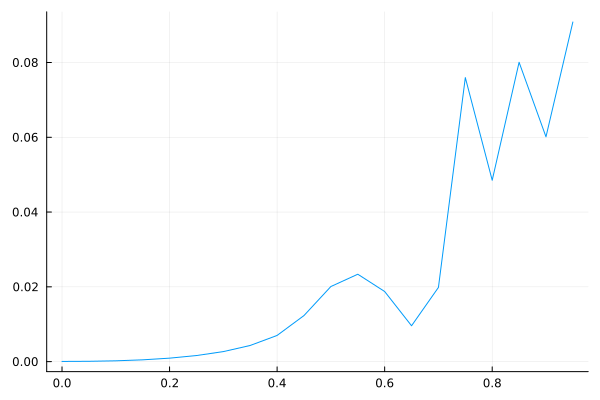

In [10]:
plot(0:0.05:0.95,thrust_dif,legend=false)

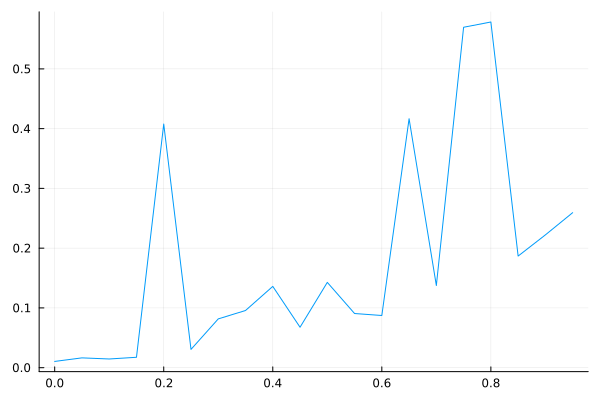

In [11]:
plot(0:0.05:0.95,max_rdif,legend=false)

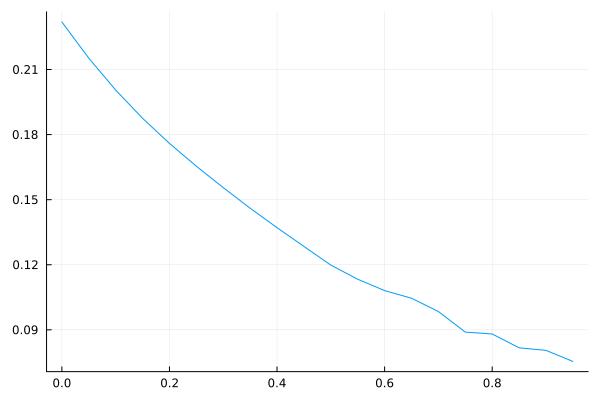

In [13]:
plot(0:0.05:0.95,thrust_ana,legend=false)